In [1]:
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [2]:
# Paths and config
DATA_ROOT = Path(r"C:\Users\HP\Desktop\pneumonia_ai_v1\data\chest_xray")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [ ]:

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


In [4]:
# Datasets and loaders
train_ds = datasets.ImageFolder(root=DATA_ROOT / "train", transform=train_transform)
val_ds   = datasets.ImageFolder(root=DATA_ROOT / "val",   transform=val_test_transform)
test_ds  = datasets.ImageFolder(root=DATA_ROOT / "test",  transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)

class_names = train_ds.classes
print("Classes:", class_names)


Classes: ['NORMAL', 'PNEUMONIA']


In [5]:

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features =nn.Sequential(
            nn.Conv2d(3,16,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 112x112

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 56x56

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 28x28
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*28*28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,num_classes)
        )
    def forward(self,x):
        x=self.features(x)
        x=self.classifier(x)
        return x
    
model =BaselineCNN(num_classes=2).to(device)  
print(model)  

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


Loss, optimizer, and class weights

In [27]:
# class  weights for imbalance
labels_np =np.array(train_ds.targets)
class_counts= np.bincount(labels_np) # [count_normal, count_pneumonia]
print("Train class counts:", class_counts)

total =class_counts.sum()
class_weights = total / (2 * class_counts)
class_weights_tensor = torch.tensor(class_weights,dtype=torch.float32).to(device)
print("Class weights:", class_weights_tensor)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Train class counts: [1073 3101]
Class weights: tensor([1.9450, 0.6730])


Train / eval loops

In [28]:
def train_one_epoch(model,loader,optimizer,criterion,device):
    model.train()
    running_loss=0.0
    correct =0
    total=0
    
    for images, labels in loader:
        images =images.to(device)
        labels =labels.to(device)

        optimizer.zero_grad()
        outputs =model(images)
        loss =criterion(outputs,labels)
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()* images.size(0)
        _,preds =outputs.max(1)
        correct+=(preds==labels).sum().item()
        total+=labels.size(0)
    return running_loss /total , correct/total

@torch.no_grad()
def evaluate(model, loader, criterion,device):
    model.eval()
    running_loss=0.0
    correct =0
    total=0

    for images, labels in loader:
        images =images.to(device)
        labels =labels.to(device)

        outputs =model(images)
        loss =criterion(outputs,labels)

        running_loss+=loss.item()* images.size(0)
        _,preds =outputs.max(1)
        correct+=(preds==labels).sum().item()
        total+=labels.size(0)

    return running_loss /total , correct/ total

In [29]:
num_epochs = 10
best_val_loss = float("inf")
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

os.makedirs("artifacts/models", exist_ok=True)

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"- train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} "
          f"- val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "artifacts/models/baseline_cnn_best.pth")
        print("  -> Saved new best model")


Epoch 1/10 - train_loss: 0.0181, train_acc: 0.9940 - val_loss: 0.0958, val_acc: 0.9849
  -> Saved new best model
Epoch 2/10 - train_loss: 0.0403, train_acc: 0.9890 - val_loss: 0.0871, val_acc: 0.9783
  -> Saved new best model
Epoch 3/10 - train_loss: 0.0263, train_acc: 0.9904 - val_loss: 0.0810, val_acc: 0.9877
  -> Saved new best model
Epoch 4/10 - train_loss: 0.0144, train_acc: 0.9950 - val_loss: 0.0806, val_acc: 0.9858
  -> Saved new best model
Epoch 5/10 - train_loss: 0.0119, train_acc: 0.9959 - val_loss: 0.0893, val_acc: 0.9858
Epoch 6/10 - train_loss: 0.0128, train_acc: 0.9952 - val_loss: 0.1018, val_acc: 0.9868
Epoch 7/10 - train_loss: 0.0239, train_acc: 0.9921 - val_loss: 0.0906, val_acc: 0.9820
Epoch 8/10 - train_loss: 0.0111, train_acc: 0.9959 - val_loss: 0.1175, val_acc: 0.9839
Epoch 9/10 - train_loss: 0.0064, train_acc: 0.9981 - val_loss: 0.0969, val_acc: 0.9877
Epoch 10/10 - train_loss: 0.0051, train_acc: 0.9986 - val_loss: 0.1247, val_acc: 0.9839


Plot training curves

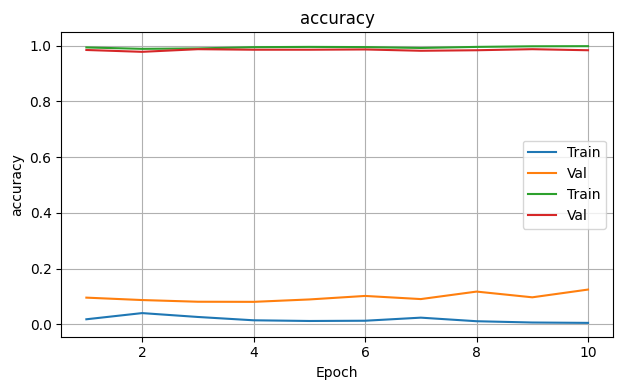

In [30]:
epochs=range(1,num_epochs+1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs,history["train_loss"], label="Train")
plt.plot(epochs, history["val_loss"],   label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,1)
plt.plot(epochs,history["train_acc"], label="Train")
plt.plot(epochs, history["val_acc"],   label="Val")
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.title("accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Final test evaluation (confusion matrix + report)

In [31]:
best_model = BaselineCNN(num_classes=2).to(device)
best_model.load_state_dict(torch.load("artifacts/models/baseline_cnn_best.pth", map_location=device))
best_model.eval()


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [32]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        _, preds = outputs.max(1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


Confusion matrix:
 [[ 80 154]
 [  6 384]]


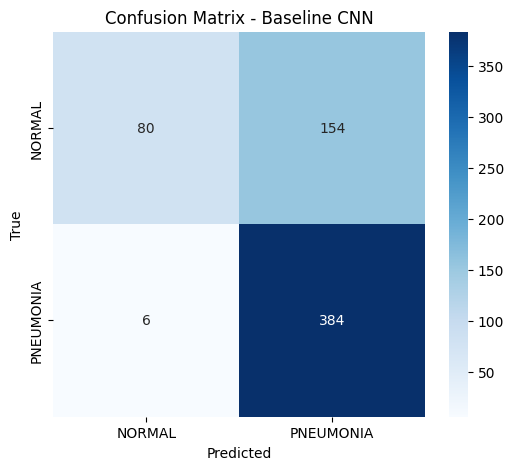


Classification report:
              precision    recall  f1-score   support

      NORMAL       0.93      0.34      0.50       234
   PNEUMONIA       0.71      0.98      0.83       390

    accuracy                           0.74       624
   macro avg       0.82      0.66      0.66       624
weighted avg       0.79      0.74      0.70       624



In [33]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

plt.figure(figsize=(6, 5))  # width=6, height=5
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Baseline CNN")
plt.show()

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names))
